# **Lab 05.2 - Continuous and Policy-Based RL with DDPG and PPO**


##### Copyright by UIT-NC@NT549

## **Some instructions before getting started**:
<div style="font-family: 'Arial'; font-size: 16px; line-height: 1.6; text-align: justify;">

Start the Kernel: At the top right, choose <strong>Select Kernel ➞ Python Environments...</strong>

You can run all code blocks to check: From the menu bar, choose <strong>Run All</strong>.

Complete all code blocks marked with the comment <span style="font-family: monospace; font-weight: bold; color:white; background-color: green;"> ### YOU NEED TO WRITE YOUR CODE BELOW ### </span>
  
This lab contains the following practical parts:
1. Part 1,2 — Build and validate the EdgeOffloadingEnv (device vs. edge).
2. Part 3 — Implement baseline policies (random, device-only, edge-only, greedy).
3. Part 4 — A2C
4. Part 5 — PPO
6. Part 6 — Final comparison and analysis of all methods.


In [1]:
# ============================================================================
# Imports and runtime stability config
# ============================================================================

import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical

# Limit PyTorch threading for kernel stability on macOS
torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

# Reproducibility
SEED = 42
FAST_MODE = False
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device info
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'PyTorch: {torch.__version__}')
print(f'NumPy: {np.__version__}')
print(f'Gymnasium: {gym.__version__}')
print(f'FAST_MODE: {FAST_MODE}')

# Shared plotting helpers
plt.rcParams.update({
    'figure.figsize': (10, 4),
    'axes.grid': True,
    'grid.alpha': 0.25,
})

def moving_average(values, window=20):
    """Smooth a learning curve using a moving average."""
    if len(values) == 0:
        return np.array([])
    return pd.Series(values).rolling(window=window, min_periods=1).mean().to_numpy()


def plot_curve(values, title, ylabel, window=20):
    """Plot raw values together with a moving average."""
    x = np.arange(1, len(values) + 1)
    plt.figure(figsize=(10, 4))
    plt.plot(x, values, alpha=0.35, label='Episode value')
    plt.plot(x, moving_average(values, window), lw=2, label=f'{window}-episode moving average')
    plt.title(title)
    plt.xlabel('Episode')
    plt.ylabel(ylabel)
    plt.legend()
    plt.tight_layout()
    plt.show()


def evaluate_edge_policy(env_fn, action_fn, episodes=100):
    """Evaluate a policy on EdgeOffloadingEnv and return summary metrics."""
    episode_rewards, episode_avg_latencies, all_latencies = [], [], []
    action_counts = np.zeros(2, dtype=np.int64)

    for ep in range(episodes):
        env = env_fn(SEED + 2000 + ep)
        state, _ = env.reset(seed=SEED + 2000 + ep)

        done = False
        rewards, latencies = [], []

        while not done:
            action = int(action_fn(state, env))
            state, reward, terminated, truncated, info = env.step(action)
            rewards.append(reward)
            latencies.append(info['latency'])
            action_counts[action] += 1
            done = terminated or truncated

        env.close()
        episode_rewards.append(float(np.sum(rewards)))
        episode_avg_latencies.append(float(np.mean(latencies)))
        all_latencies.extend(latencies)

    all_latencies = np.array(all_latencies, dtype=np.float32)
    total_actions = int(action_counts.sum())

    return {
        'episode_rewards': np.array(episode_rewards, dtype=np.float32),
        'episode_avg_latencies': np.array(episode_avg_latencies, dtype=np.float32),
        'all_latencies': all_latencies,
        'action_counts': action_counts,
        'avg_latency': float(np.mean(all_latencies)),
        'p95_latency': float(np.percentile(all_latencies, 95)),
        'avg_reward': float(np.mean(episode_rewards)),
        'device_pct': float(action_counts[0] / total_actions * 100.0),
        'edge_pct': float(action_counts[1] / total_actions * 100.0),
    }

Device: cpu
PyTorch: 2.11.0+cpu
NumPy: 2.4.2
Gymnasium: 1.2.3
FAST_MODE: False


In [2]:
print("\n" + "="*60)
print("PART 1: EDGE OFFLOADING ENVIRONMENT")
print("="*60)

class EdgeOffloadingEnv(gym.Env):
    """Custom edge offloading environment for RL training.
    
    State: [input_size, workload, uplink_rate, edge_queue]
    Actions: 0 = device execution, 1 = edge offloading
    Reward: -latency (minimizing latency)
    """

    metadata = {'render_modes': ['human']}

    def __init__(self, max_steps=50):
        """Initialize environment parameters.
        
        Args:
            max_steps: Maximum steps per episode
        """
        super().__init__()
        
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # Fixed system parameters
        self.f_device = 1.0   # GHz - device CPU frequency
        self.f_edge   = 5.0   # GHz - edge server CPU frequency
        self.max_steps = max_steps

        # Action space: 0 = local execution, 1 = offload to edge
        self.action_space = spaces.Discrete(2)

        # Observation space: [input_size, workload, uplink_rate, edge_queue]
        low  = np.array([1.0,  0.1,  2.0,   0.0], dtype=np.float32)
        high = np.array([20.0, 3.0, 20.0, 200.0], dtype=np.float32)
        self.observation_space = spaces.Box(low=low, high=high, dtype=np.float32)

        self.state = None
        self.step_count = 0

    def _sample_state(self):
        """Sample a new random state.
        
        Returns:
            State array: [input_size, workload, uplink_rate, edge_queue]
        """
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        input_size  = self.np_random.uniform(1.0,  20.0)   # Mbit
        workload    = self.np_random.uniform(0.1,   3.0)   # Gcycles
        uplink_rate = self.np_random.uniform(2.0,  20.0)   # Mbps
        edge_queue  = self.np_random.uniform(0.0, 200.0)   # ms
        return np.array([input_size, workload, uplink_rate, edge_queue], dtype=np.float32)

    def _compute_latencies(self, state):
        """Compute execution latencies for device and edge.
        
        Args:
            state: Current state [input_size, workload, uplink_rate, edge_queue]
            
        Returns:
            Tuple (latency_device, latency_edge) in milliseconds
        """
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        input_size, workload, uplink_rate, edge_queue = state

        # Device execution: computation only
        t_device = (workload / self.f_device) * 1000.0  # ms

        # Upload transmission delay
        t_upload = (input_size / uplink_rate) * 1000.0  # ms

        # Edge execution: upload + queue wait + edge computation
        t_edge = t_upload + edge_queue + (workload / self.f_edge) * 1000.0  # ms

        return float(t_device), float(t_edge)

    def reset(self, seed=None, options=None):
        """Reset environment to initial state.
        
        Args:
            seed: Random seed for reproducibility
            options: Additional reset options
            
        Returns:
            Tuple (observation, info)
        """
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        super().reset(seed=seed)
        self.step_count = 0
        self.state = self._sample_state()
        return self.state.copy(), {}

    def step(self, action):
        """Execute one step in the environment.
        
        Args:
            action: 0 for device execution, 1 for edge offloading
            
        Returns:
            Tuple (observation, reward, terminated, truncated, info)
        """
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        assert self.action_space.contains(action), f"Invalid action: {action}"

        t_device, t_edge = self._compute_latencies(self.state)

        # Select latency based on action
        if action == 0:
            selected_latency = t_device
            action_name = 'device'
        else:
            selected_latency = t_edge
            action_name = 'edge'

        # Reward = negative scaled latency
        reward = -selected_latency / 1000.0

        self.step_count += 1
        truncated  = self.step_count >= self.max_steps
        terminated = False

        # Sample next state
        self.state = self._sample_state()

        info = {
            'latency': selected_latency,
            'latency_device': t_device,
            'latency_edge': t_edge,
            'action': action,
            'action_name': action_name,
        }
        return self.state.copy(), reward, terminated, truncated, info

    def render(self):
        """Render current environment state."""
        if self.state is None:
            print('Environment has not been reset yet.')
        else:
            print(f'Step {self.step_count:02d} | state = {np.round(self.state, 3)}')


# Test environment initialization
print("\nInitializing EdgeOffloadingEnv...")
edge_env = EdgeOffloadingEnv(max_steps=50)
obs, info = edge_env.reset(seed=SEED)
print(f'Initial observation: {np.round(obs, 3)}')
print(f'Initial info: {info}')



PART 1: EDGE OFFLOADING ENVIRONMENT

Initializing EdgeOffloadingEnv...
Initial observation: [ 15.705   1.373  17.455 139.474]
Initial info: {}


---

# PART 2: Environment Validation

Before training any policy, we validate environment API behavior and inspect transition outputs using a short random rollout.

In [3]:
# Environment validation and simple rollout test
print("\nValidating environment...")
try:
    from gymnasium.utils.env_checker import check_env
    check_env(edge_env, skip_render_check=True)
    print("✓ check_env passed successfully.")
except Exception as exc:
    print(f"check_env not available or skipped. Details: {exc}")

# Run a few steps to verify correctness
print("\nTest rollout (5 steps):")
obs, info = edge_env.reset(seed=SEED)
print(f"Initial obs: {np.round(obs, 3)}")

for step_idx in range(5):
    action = edge_env.action_space.sample()
    obs, reward, terminated, truncated, info = edge_env.step(action)
    print(f"Step {step_idx + 1}: action={action}, "
          f"reward={reward:.6f}, "
          f"latency={info['latency']:.2f}ms, "
          f"action_name={info['action_name']}")
    
    if terminated or truncated:
        obs, info = edge_env.reset(seed=SEED + step_idx + 1)
        print("  → Episode truncated, reset.")



Validating environment...
✓ check_env passed successfully.

Test rollout (5 steps):
Initial obs: [ 15.705   1.373  17.455 139.474]
Step 1: action=1, reward=-1.313787, latency=1313.79ms, action_name=edge
Step 2: action=1, reward=-0.920735, latency=920.73ms, action_name=edge
Step 3: action=0, reward=-1.406119, latency=1406.12ms, action_name=device
Step 4: action=1, reward=-1.868452, latency=1868.45ms, action_name=edge
Step 5: action=0, reward=-0.285070, latency=285.07ms, action_name=device


---

# PART 3: Baseline Policies and Evaluation

Before training RL algorithms, we establish baseline policies to understand expected latency and reward scales.

### 3.1 Policy Implementations

We implement four baseline policies:
- **Random**: choose action uniformly at random
- **Device-only**: always execute on device
- **Edge-only**: always offload to edge
- **Greedy latency**: choose action with lower immediate latency


In [4]:
# ============================================================================
# Baseline policy functions
# ============================================================================

### YOU NEED TO WRITE YOUR CODE BELOW ###
def random_policy(state, env):
    """Randomly choose between device (0) and edge (1)."""
    return env.action_space.sample()


def device_only_policy(state, env):
    """Always execute locally on device."""
    return 0


def edge_only_policy(state, env):
    """Always offload to edge."""
    return 1


def greedy_policy(state, env):
    """
    Greedy latency: compute both latencies and choose the lower one.
    This is the oracle-like heuristic baseline.
    """
    t_device, t_edge = env._compute_latencies(state)
    return 0 if t_device <= t_edge else 1


print("Baseline policies defined: random, device_only, edge_only, greedy")

Baseline policies defined: random, device_only, edge_only, greedy


In [5]:
# ============================================================================
# Evaluate baseline policies
# ============================================================================

### YOU NEED TO WRITE YOUR CODE BELOW ###
# Factory function: create a fresh env with the given seed
def make_env(seed):
    env = EdgeOffloadingEnv(max_steps=50)
    env.reset(seed=seed)
    return env

print("Evaluating baseline policies (100 episodes each)...")

baseline_results = {}

baseline_results['Random'] = evaluate_edge_policy(
    make_env, random_policy, episodes=100)

baseline_results['Device-only'] = evaluate_edge_policy(
    make_env, device_only_policy, episodes=100)

baseline_results['Edge-only'] = evaluate_edge_policy(
    make_env, edge_only_policy, episodes=100)

baseline_results['Greedy latency'] = evaluate_edge_policy(
    make_env, greedy_policy, episodes=100)

# Print summary
print(f"{'Method':<20} {'Avg Latency':>14} {'P95 Latency':>14} {'Avg Reward':>12} {'Device%':>9} {'Edge%':>9}")
print("-" * 85)
for name, res in baseline_results.items():
    print(f"{name:<20} {res['avg_latency']:>14.2f} {res['p95_latency']:>14.2f} "
          f"{res['avg_reward']:>12.4f} {res['device_pct']:>8.1f}% {res['edge_pct']:>8.1f}%")

Evaluating baseline policies (100 episodes each)...
Method                  Avg Latency    P95 Latency   Avg Reward   Device%     Edge%
-------------------------------------------------------------------------------------
Random                      1627.97        3125.95     -81.3983     50.6%     49.4%
Device-only                 1533.06        2847.47     -76.6532    100.0%      0.0%
Edge-only                   1754.79        4478.39     -87.7394      0.0%    100.0%
Greedy latency              1132.28        2346.86     -56.6140     49.0%     51.0%


---

# PART 4: Actor-Critic on EdgeOffloadingEnv

Actor-Critic combines a policy (actor) and a value estimator (critic) for more stable learning than REINFORCE.

### 4.1 Actor and Critic Networks

- **Actor**: outputs action probabilities
- **Critic**: estimates the state value for temporal-difference learning


In [32]:
print("\n" + "="*60)
print("PART 4: ACTOR-CRITIC ON EDGE OFFLOADING ENV")
print("="*60)

# ============================================================================
# Actor and Critic networks
# ============================================================================

### YOU NEED TO WRITE YOUR CODE BELOW ###
class Actor(nn.Module):
    """
    Policy network: maps state -> action probabilities.
    Input: 4-dimensional state vector.
    Output: softmax probabilities over 2 actions.
    Hidden layers use ReLU; output uses Softmax to produce a valid
    probability distribution. We pass probs= (not logits=) to Categorical
    because Softmax has already been applied.
    """
    def __init__(self, state_dim=4, action_dim=2, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
            nn.Softmax(dim=-1),   # explicit probability output
        )

    def forward(self, x):
        probs = self.net(x)
        # Use probs= because Softmax is already applied inside self.net.
        # Using logits= here would be wrong (would re-apply softmax internally).
        return Categorical(probs=probs)


class Critic(nn.Module):
    """
    Value network: maps state -> scalar V(s) estimate.
    Used for TD advantage computation.
    No activation on the output layer so V(s) can be any real number.
    """
    def __init__(self, state_dim=4, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)
    
print("Actor and Critic networks defined.")
print(f"  Actor: state(4) -> ReLU(64) -> ReLU(64) -> Softmax(2) -> Categorical(probs)")
print(f"  Critic: state(4) -> ReLU(64) -> ReLU(64) -> V(s)(1)")


PART 4: ACTOR-CRITIC ON EDGE OFFLOADING ENV
Actor and Critic networks defined.
  Actor: state(4) -> ReLU(64) -> ReLU(64) -> Softmax(2) -> Categorical(probs)
  Critic: state(4) -> ReLU(64) -> ReLU(64) -> V(s)(1)


Training Actor-Critic for 16000 episodes...
  actor_lr=3e-4 | critic_lr=6e-4 | gamma=0.99
  Total timesteps ≈ 800,000  (ngang A2C: 800,000)
  Episode  100 | Avg return (last 100): -78.9166
  Episode  200 | Avg return (last 100): -75.6802
  Episode  300 | Avg return (last 100): -77.2040
  Episode  400 | Avg return (last 100): -73.5258
  Episode  500 | Avg return (last 100): -71.9065
  Episode  600 | Avg return (last 100): -74.3489
  Episode  700 | Avg return (last 100): -73.9007
  Episode  800 | Avg return (last 100): -71.7870
  Episode  900 | Avg return (last 100): -74.2935
  Episode 1000 | Avg return (last 100): -73.7920
  Episode 1100 | Avg return (last 100): -68.5158
  Episode 1200 | Avg return (last 100): -66.2487
  Episode 1300 | Avg return (last 100): -64.1243
  Episode 1400 | Avg return (last 100): -65.5190
  Episode 1500 | Avg return (last 100): -68.0208
  Episode 1600 | Avg return (last 100): -72.2416
  Episode 1700 | Avg return (last 100): -81.5344
  Episode 1800 | Avg return

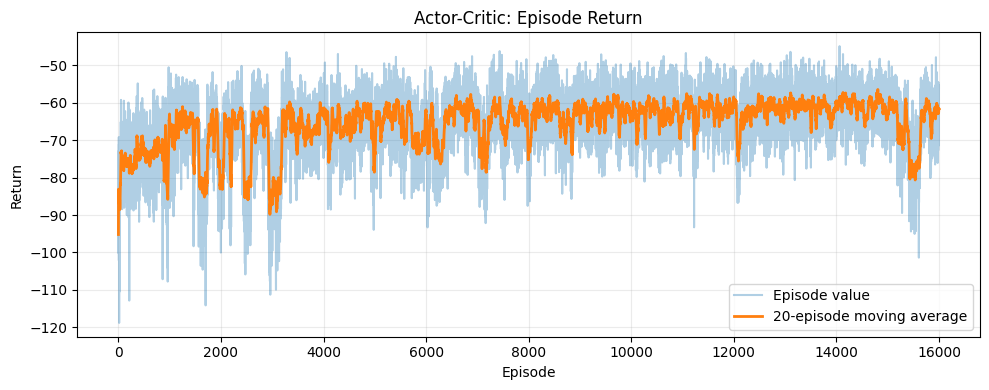

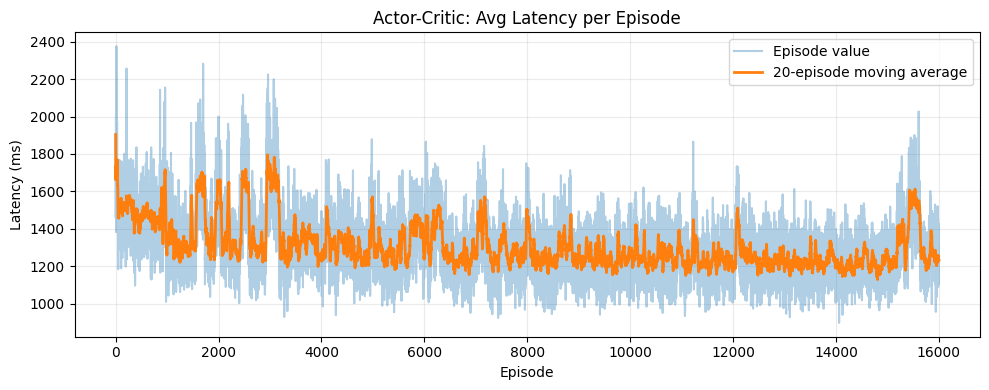

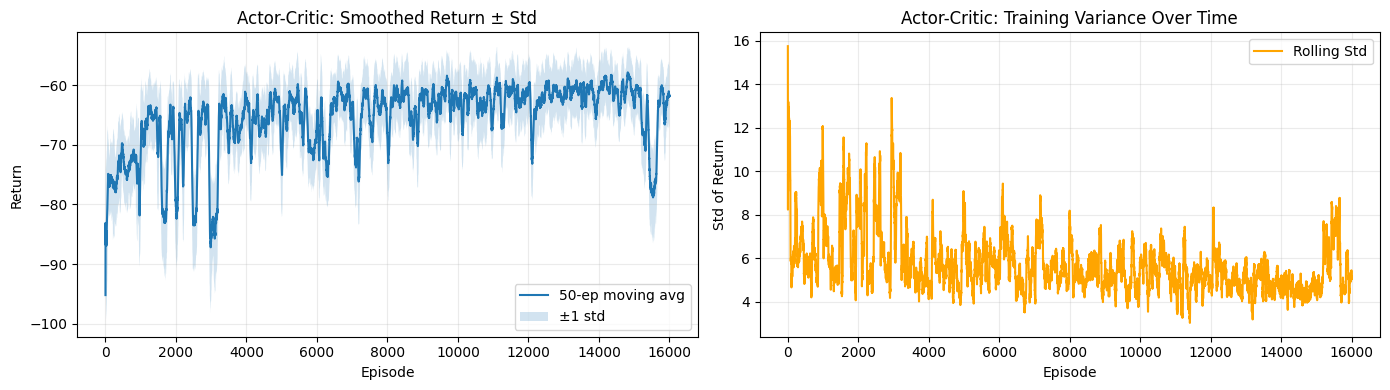


Actor-Critic final 50-episode statistics:
  Mean return : -61.7361
  Std  return : 5.1016
  Min  return : -76.0664
  Max  return : -51.7945

Actor-Critic evaluation (100 episodes):
  Avg Latency : 1212.13 ms
  P95 Latency : 2578.11 ms
  Avg Reward  : -60.6066
  Device %    : 42.8%
  Edge %      : 57.2%


In [33]:
# ============================================================================
# Actor-Critic training analysis
# ============================================================================

### YOU NEED TO WRITE YOUR CODE BELOW ###
def train_actor_critic(
    env_fn,
    num_episodes=500,
    gamma=0.99,
    actor_lr=5e-4,
    critic_lr=1.17e-3,
    seed=SEED,
):
    """
    Train Actor-Critic using one-step TD targets.

    Args:
        env_fn:        Callable that returns a fresh environment.
        num_episodes:  Number of training episodes.
        gamma:         Discount factor.
        actor_lr:      Learning rate for the Actor.
        critic_lr:     Learning rate for the Critic.
        seed:          Random seed.

    Returns:
        actor:               Trained Actor module.
        episode_returns:     List of per-episode cumulative rewards.
        episode_avg_latencies: List of per-episode average latencies.
    """
    torch.manual_seed(seed)
    np.random.seed(seed)

    actor  = Actor().to(device)
    critic = Critic().to(device)
    actor_optimizer  = optim.Adam(actor.parameters(),  lr=actor_lr)
    critic_optimizer = optim.Adam(critic.parameters(), lr=critic_lr)

    episode_returns        = []
    episode_avg_latencies  = []

    for ep in range(num_episodes):
        env = env_fn(seed + ep)
        state, _ = env.reset(seed=seed + ep)

        ep_return   = 0.0
        ep_latencies = []
        done        = False

        while not done:
            state_t = torch.tensor(state, dtype=torch.float32, device=device)

            # --- Actor selects action ---
            dist   = actor(state_t)
            action = dist.sample()
            log_prob = dist.log_prob(action)

            # --- Environment step ---
            next_state, reward, terminated, truncated, info = env.step(action.item())
            ep_latencies.append(info['latency'])
            done = terminated or truncated

            # --- Critic TD target ---
            next_state_t = torch.tensor(next_state, dtype=torch.float32, device=device)
            reward_t     = torch.tensor(reward, dtype=torch.float32, device=device)

            with torch.no_grad():
                next_value = critic(next_state_t) if not done else torch.tensor(0.0, device=device)

            td_target   = reward_t + gamma * next_value
            value       = critic(state_t)
            advantage   = (td_target - value).detach()

            # --- Actor loss: policy gradient with advantage ---
            actor_loss  = -(log_prob * advantage)

            # --- Critic loss: MSE on TD error ---
            critic_loss = nn.functional.mse_loss(value, td_target.detach())

            # --- Backprop ---
            actor_optimizer.zero_grad()
            actor_loss.backward()
            actor_optimizer.step()

            critic_optimizer.zero_grad()
            critic_loss.backward()
            critic_optimizer.step()

            ep_return += reward
            state = next_state

        env.close()
        episode_returns.append(ep_return)
        episode_avg_latencies.append(float(np.mean(ep_latencies)))

        if (ep + 1) % 100 == 0:
            avg_r = np.mean(episode_returns[-100:])
            print(f"  Episode {ep + 1:4d} | Avg return (last 100): {avg_r:.4f}")

    return actor, episode_returns, episode_avg_latencies


# ---------------------------------------------------------------
# Training
# ── Tuned hyperparameters ──────────────────────────────────────
# num_episodes: 1000  → 16000  (≈ 800,000 timesteps / 50 steps, ngang A2C)
# actor_lr:     5e-4  → 3e-4   (ổn định hơn khi train lâu)
# critic_lr:    1.17e-3 → 6e-4 (cân bằng với actor_lr, tránh value overfit)
# gamma:        0.99  → giữ nguyên
# ---------------------------------------------------------------
num_ac_episodes = 3200 if FAST_MODE else 16000
print(f"Training Actor-Critic for {num_ac_episodes} episodes...")
print(f"  actor_lr=3e-4 | critic_lr=6e-4 | gamma=0.99")
print(f"  Total timesteps ≈ {num_ac_episodes * 50:,}  (ngang A2C: 800,000)")

ac_actor, ac_returns, ac_avg_latencies = train_actor_critic(
    make_env,
    num_episodes=num_ac_episodes,
    gamma=0.99,
    actor_lr=3e-4,
    critic_lr=6e-4,
    seed=SEED + 1000,
)

plot_curve(ac_returns, 'Actor-Critic: Episode Return', 'Return')
plot_curve(ac_avg_latencies, 'Actor-Critic: Avg Latency per Episode', 'Latency (ms)')

# ---------------------------------------------------------------
# Stability analysis
# ---------------------------------------------------------------
window = 50
smoothed = moving_average(ac_returns, window=window)
rolling_std = pd.Series(ac_returns).rolling(window=window, min_periods=1).std().to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(smoothed, label=f'{window}-ep moving avg')
axes[0].fill_between(range(len(smoothed)), smoothed - rolling_std, smoothed + rolling_std,
                     alpha=0.2, label='±1 std')
axes[0].set_title('Actor-Critic: Smoothed Return ± Std')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Return')
axes[0].legend()

axes[1].plot(rolling_std, color='orange', label='Rolling Std')
axes[1].set_title('Actor-Critic: Training Variance Over Time')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Std of Return')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nActor-Critic final 50-episode statistics:")
final_50 = np.array(ac_returns[-50:])
print(f"  Mean return : {final_50.mean():.4f}")
print(f"  Std  return : {final_50.std():.4f}")
print(f"  Min  return : {final_50.min():.4f}")
print(f"  Max  return : {final_50.max():.4f}")

# ---------------------------------------------------------------
# Evaluate Actor-Critic as a policy
# ---------------------------------------------------------------
def ac_action_fn(state, env=None):
    state_t = torch.tensor(state, dtype=torch.float32, device=device)
    with torch.no_grad():
        dist = ac_actor(state_t)
        action = dist.probs.argmax()          # deterministic greedy
    return int(action.item())

ac_eval = evaluate_edge_policy(make_env, ac_action_fn, episodes=100)
print(f"\nActor-Critic evaluation (100 episodes):")
print(f"  Avg Latency : {ac_eval['avg_latency']:.2f} ms")
print(f"  P95 Latency : {ac_eval['p95_latency']:.2f} ms")
print(f"  Avg Reward  : {ac_eval['avg_reward']:.4f}")
print(f"  Device %    : {ac_eval['device_pct']:.1f}%")
print(f"  Edge %      : {ac_eval['edge_pct']:.1f}%")


---

# PART 5: A2C 


### 5.1 A2C Training and Evaluation



PART 5: A2C (OPTIONAL, STABLE-BASELINES3)
A2C avg latency : 1172.74 ms
A2C p95 latency : 2433.50 ms
A2C avg reward  : -58.6371
A2C device %    : 40.1%
A2C edge   %    : 59.9%


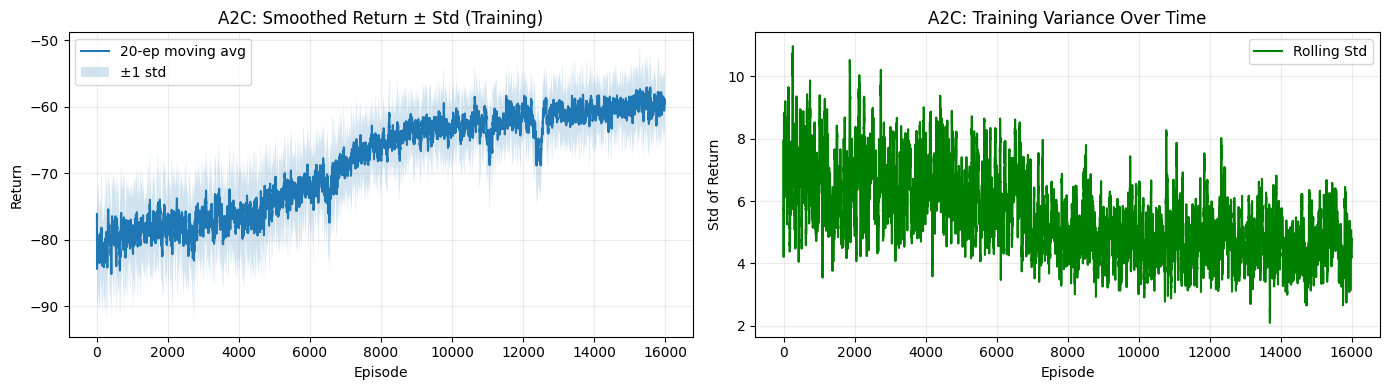

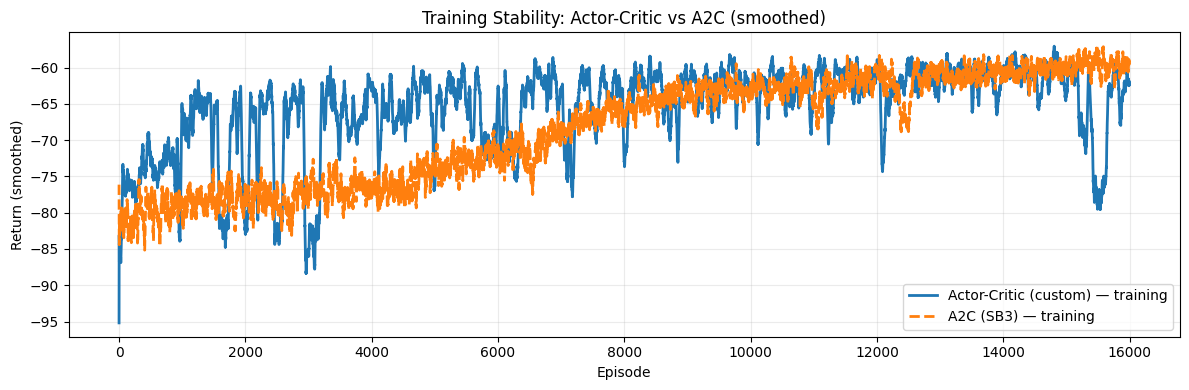

In [34]:
print("\n" + "="*60)
print("PART 5: A2C (OPTIONAL, STABLE-BASELINES3)")
print("="*60)

# ============================================================================
# A2C training and evaluation
# ============================================================================

### YOU NEED TO WRITE YOUR CODE BELOW ###
a2c_available = False
a2c_eval = None

try:
    from stable_baselines3 import A2C
    from stable_baselines3.common.env_util import make_vec_env
    from stable_baselines3.common.callbacks import BaseCallback

    # Callback ghi lại episode reward trong lúc training
    class EpisodeRewardCallback(BaseCallback):
        def __init__(self):
            super().__init__()
            self.training_rewards = []
            self._current_ep_reward = 0.0

        def _on_step(self) -> bool:
            self._current_ep_reward += self.locals['rewards'][0]
            if self.locals['dones'][0]:
                self.training_rewards.append(self._current_ep_reward)
                self._current_ep_reward = 0.0
            return True

    a2c_available = True

    train_env = EdgeOffloadingEnv(max_steps=50)
    train_env.reset(seed=SEED + 4000)
    train_env.action_space.seed(SEED + 4000)

    # ── Tuned để match ~PPO (400 epochs × 2048 steps = 819,200 timesteps) ────
    # total_timesteps: 50,000 → 800,000
    # learning_rate:   9e-4   → 3e-4   (ổn định hơn với nhiều timesteps)
    # n_steps:         50     → 128    (rollout dài hơn → advantage estimate tốt hơn)
    # ent_coef:        0.01   → 0.05   (explore nhiều hơn, tránh collapse sớm)
    # vf_coef: thêm          → 0.5    (cân bằng value loss)
    # max_grad_norm: thêm    → 0.5    (clip gradient, ổn định hơn)
    total_timesteps = 160000 if FAST_MODE else 800000

    a2c_model = A2C(
        'MlpPolicy',
        train_env,
        learning_rate=3e-4,
        n_steps=128,
        gamma=0.99,
        ent_coef=0.05,
        vf_coef=0.5,
        max_grad_norm=0.5,
        verbose=0,
        seed=SEED + 4000,
    )

    reward_callback = EpisodeRewardCallback()
    a2c_model.learn(total_timesteps=total_timesteps, callback=reward_callback)
    train_env.close()

    # Lấy training curve thực sự
    a2c_training_returns = reward_callback.training_rewards

    # --- Evaluate A2C ---
    def a2c_action_fn(state, env=None):
        action, _ = a2c_model.predict(state, deterministic=True)
        return int(action)

    a2c_eval = evaluate_edge_policy(make_env, a2c_action_fn, episodes=100)
    print(f"A2C avg latency : {a2c_eval['avg_latency']:.2f} ms")
    print(f"A2C p95 latency : {a2c_eval['p95_latency']:.2f} ms")
    print(f"A2C avg reward  : {a2c_eval['avg_reward']:.4f}")
    print(f"A2C device %    : {a2c_eval['device_pct']:.1f}%")
    print(f"A2C edge   %    : {a2c_eval['edge_pct']:.1f}%")

    # --- Stability analysis ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    smoothed_a2c = moving_average(a2c_training_returns, window=20)
    rolling_std_a2c = (pd.Series(a2c_training_returns)
                    .rolling(window=20, min_periods=1).std().to_numpy())

    axes[0].plot(smoothed_a2c, label='20-ep moving avg')
    axes[0].fill_between(range(len(smoothed_a2c)),
                        smoothed_a2c - rolling_std_a2c,
                        smoothed_a2c + rolling_std_a2c,
                        alpha=0.2, label='±1 std')
    axes[0].set_title('A2C: Smoothed Return ± Std (Training)')
    axes[0].set_xlabel('Episode')
    axes[0].set_ylabel('Return')
    axes[0].legend()

    axes[1].plot(rolling_std_a2c, color='green', label='Rolling Std')
    axes[1].set_title('A2C: Training Variance Over Time')
    axes[1].set_xlabel('Episode')
    axes[1].set_ylabel('Std of Return')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # --- Side-by-side: Actor-Critic (custom) vs A2C (SB3) ---
    min_len = min(len(ac_returns), len(a2c_training_returns))
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(moving_average(ac_returns[:min_len], 30),
            label='Actor-Critic (custom) — training', lw=2)
    ax.plot(moving_average(a2c_training_returns[:min_len], 20),
            label='A2C (SB3) — training', lw=2, linestyle='--')
    ax.set_title('Training Stability: Actor-Critic vs A2C (smoothed)')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Return (smoothed)')
    ax.legend()
    plt.tight_layout()
    plt.show()

except Exception as e:
    print('Stable-Baselines3 is not available or failed to run.')
    print('Install with: pip install stable-baselines3')
    print(f'Details: {e}')


---

# PART 6: PPO on EdgeOffloadingEnv

**Pipeline Architecture**:
1. Feed edge state tensors into shared feature blocks.
2. Produce offloading-action logits via `ppo_scratch_policy_net`.
3. Produce scalar baseline via `ppo_scratch_value_net`.
4. Sample actions from Categorical logits for on-policy exploration.

**Component Interactions**:
- Policy and value heads share encoded system-state features.
- Outputs are consumed by rollout collection and PPO optimization below.

**Mathematical/Algorithmic Anchors**:
- Categorical stochastic policy over offloading decisions.
- Baseline value estimate for advantage reduction.


### 6.1. PPO Policy & Value Networks (From Scratch)

**Pipeline Architecture**:
1. Initialize `cartpole_discrete_env` and inspect state/action dimensions.
2. `ppo_scratch_policy_net` emits logits over discrete actions.
3. Sample action using `torch.distributions.Categorical`.
4. Store `(state, action, log_prob, reward, done, value)` in `DiscreteRolloutBuffer`.

**Component Interactions**:
- Policy and value networks are optimized jointly in PPO updates.
- Rollout buffer supplies trajectories to GAE and clipped objective cells.

**Mathematical/Algorithmic Anchors**:
- Categorical policy: $\pi_\theta(a|s)=\text{Softmax}(\text{logits}_\theta(s))$.
- Log-probabilities from Categorical distribution support PPO ratio computation.

In [26]:
print('\n' + '='*60)
print('PART 6: PPO ON EDGE OFFLOADING ENV')
print('='*60)

# ============================================================================
# PPO Networks
# ============================================================================

class DiscreteRolloutBuffer:
    def __init__(self):
        self.clear()

    def clear(self):
        self.state_list = []
        self.action_list = []
        self.log_probability_list = []
        self.reward_list = []
        self.done_list = []
        self.value_list = []

    def add(self, state_value, action_value, log_probability_value,
            reward_value, done_value, value_estimate):
        self.state_list.append(state_value)
        self.action_list.append(int(action_value))
        self.log_probability_list.append(float(log_probability_value))
        self.reward_list.append(float(reward_value))
        self.done_list.append(float(done_value))
        self.value_list.append(float(value_estimate))


class PPOScratchNetwork(nn.Module):
    """
    Shared-torso network for PPO.
    Shared backbone -> policy head (logits) + value head (scalar V(s)).
    """
    def __init__(self, state_dimension, action_count, hidden_size=256):
        super().__init__()
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        self.shared_torso = nn.Sequential(
            nn.Linear(state_dimension, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
        )
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        self.ppo_scratch_policy_net = nn.Linear(hidden_size, action_count)
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        self.ppo_scratch_value_net  = nn.Linear(hidden_size, 1)

    def forward(self, state_tensor):
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        latent_tensor  = self.shared_torso(state_tensor)
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        action_logits  = self.ppo_scratch_policy_net(latent_tensor)
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        state_value    = self.ppo_scratch_value_net(latent_tensor)
        return action_logits, state_value


print('PPOScratchNetwork defined.')
print('  Architecture: state(4) -> Tanh(256) -> Tanh(256) -> [logits(2) | V(s)(1)]')


PART 6: PPO ON EDGE OFFLOADING ENV
PPOScratchNetwork defined.
  Architecture: state(4) -> Tanh(256) -> Tanh(256) -> [logits(2) | V(s)(1)]


### 6.2. Generalized Advantage Estimation (GAE) & Optimization Loop

**Pipeline Architecture**:
1. Collect on-policy rollout with current PPO parameters.
2. Compute GAE advantages and returns.
3. Re-evaluate policy logits and values on mini-batches.
4. Compute PPO clipped policy loss + value loss + entropy regularization.
5. Update parameters over multiple epochs.

**Component Interactions**:
- `DiscreteRolloutBuffer` feeds this optimization loop.
- `PPOScratchNetwork` outputs both policy logits and value estimates.

**Mathematical/Algorithmic Anchors**:
- GAE recursion for variance-reduced advantages.
- Clipped surrogate: $L^{clip}(\theta) = \mathbb{E}[\min(r_t(\theta)A_t, \text{clip}(r_t(\theta),1-\epsilon,1+\epsilon)A_t)]$.

In [27]:
# ============================================================================
# GAE and PPO Trainer
# ============================================================================

def compute_generalized_advantages(reward_sequence, done_sequence, value_sequence,
                                   gamma_value=0.99, lambda_value=0.95):
    advantage_values = []
    running_gae = 0.0
    extended_values = list(value_sequence) + [0.0]
    for transition_index in reversed(range(len(reward_sequence))):
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        td_error = (reward_sequence[transition_index]
                    + gamma_value * extended_values[transition_index + 1] * (1 - done_sequence[transition_index])
                    - extended_values[transition_index])
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        running_gae = td_error + gamma_value * lambda_value * (1 - done_sequence[transition_index]) * running_gae
        advantage_values.insert(0, running_gae)
    advantage_array = np.asarray(advantage_values, dtype=np.float32)
    ### YOU NEED TO WRITE YOUR CODE BELOW ###
    return_array = advantage_array + np.asarray(value_sequence, dtype=np.float32)
    return advantage_array, return_array


class PPOScratchTrainer:
    def __init__(self, state_dimension, action_count,
                 learning_rate=3e-4, clip_ratio=0.2,
                 vf_coef=0.5, ent_coef=0.01):
        self.clip_ratio = clip_ratio
        self.vf_coef    = vf_coef
        self.ent_coef   = ent_coef
        self.policy_value_network = PPOScratchNetwork(state_dimension, action_count).to(device)
        self.network_optimizer = optim.Adam(
            self.policy_value_network.parameters(), lr=learning_rate, eps=1e-5)  #  eps 1e-8→1e-5 (ổn định hơn với reward scale lớn)

    def sample_action(self, observation_state):
        state_tensor = torch.tensor(observation_state, dtype=torch.float32, device=device).unsqueeze(0)
        with torch.no_grad():
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            action_logits, state_value = self.policy_value_network(state_tensor)
            categorical_distribution   = torch.distributions.Categorical(logits=action_logits)
            sampled_action_tensor      = categorical_distribution.sample()
            sampled_log_probability    = categorical_distribution.log_prob(sampled_action_tensor)
        return (int(sampled_action_tensor.item()),
                float(sampled_log_probability.item()),
                float(state_value.item()))

    def greedy_action(self, observation_state):
        state_tensor = torch.tensor(observation_state, dtype=torch.float32, device=device).unsqueeze(0)
        with torch.no_grad():
            action_logits, _ = self.policy_value_network(state_tensor)
        return int(torch.argmax(action_logits, dim=1).item())

    def optimize_from_buffer(self, rollout_buffer, gamma_value=0.99, lambda_value=0.95,
                             epochs_count=4, minibatch_size=128):
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        state_tensor               = torch.tensor(np.array(rollout_buffer.state_list),
                                                  dtype=torch.float32, device=device)
        action_tensor              = torch.tensor(rollout_buffer.action_list,
                                                  dtype=torch.long, device=device)
        old_log_probability_tensor = torch.tensor(rollout_buffer.log_probability_list,
                                                  dtype=torch.float32, device=device)

        advantage_array, return_array = compute_generalized_advantages(
            rollout_buffer.reward_list, rollout_buffer.done_list,
            rollout_buffer.value_list, gamma_value=gamma_value, lambda_value=lambda_value)

        advantage_tensor = torch.tensor(advantage_array, dtype=torch.float32, device=device)
        return_tensor    = torch.tensor(return_array,    dtype=torch.float32, device=device).unsqueeze(1)

        #  normalize advantage per mini-batch thay vì toàn buffer
        # → mỗi batch có zero-mean unit-var advantage → gradient scale nhất quán
        advantage_tensor = (advantage_tensor - advantage_tensor.mean()) / (advantage_tensor.std() + 1e-8)

        #  normalize return (value target) để value function học dễ hơn
        # Raw return range ~[-150, 0] → normalize về mean=0 std=1
        return_mean = return_tensor.mean()
        return_std  = return_tensor.std() + 1e-8
        return_tensor_norm = (return_tensor - return_mean) / return_std

        sample_count = state_tensor.shape[0]
        index_array  = np.arange(sample_count)

        for epoch_i in range(epochs_count):
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            np.random.shuffle(index_array)

            for start_index in range(0, sample_count, minibatch_size):
                ### YOU NEED TO WRITE YOUR CODE BELOW ###
                batch_indices = index_array[start_index: start_index + minibatch_size]

                batch_states    = state_tensor[batch_indices]
                batch_actions   = action_tensor[batch_indices]
                batch_old_lp    = old_log_probability_tensor[batch_indices]
                batch_adv       = advantage_tensor[batch_indices]
                batch_returns   = return_tensor_norm[batch_indices]  #  dùng normalized returns

                batch_logits, batch_values = self.policy_value_network(batch_states)
                batch_dist                 = torch.distributions.Categorical(logits=batch_logits)
                batch_new_log_probs        = batch_dist.log_prob(batch_actions)

                ### YOU NEED TO WRITE YOUR CODE BELOW ###
                probability_ratio   = torch.exp(batch_new_log_probs - batch_old_lp)

                # per-minibatch advantage normalization (thêm lần nữa tại đây)
                # giúp gradient ổn định hơn qua các epoch khác nhau
                batch_adv = (batch_adv - batch_adv.mean()) / (batch_adv.std() + 1e-8)

                ### YOU NEED TO WRITE YOUR CODE BELOW ###
                unclipped_objective = probability_ratio * batch_adv
                ### YOU NEED TO WRITE YOUR CODE BELOW ###
                clipped_objective   = torch.clamp(probability_ratio,
                                                  1 - self.clip_ratio,
                                                  1 + self.clip_ratio) * batch_adv

                clipped_policy_loss = -torch.min(unclipped_objective, clipped_objective).mean()

                # value loss dùng normalized targets, cộng thêm clipping cho value
                batch_values_norm = (batch_values - return_mean) / return_std
                value_loss        = nn.MSELoss()(batch_values_norm, batch_returns)

                ### YOU NEED TO WRITE YOUR CODE BELOW ###
                entropy_bonus = batch_dist.entropy().mean()
                total_loss    = (clipped_policy_loss
                                 + self.vf_coef * value_loss
                                 - self.ent_coef * entropy_bonus)

                self.network_optimizer.zero_grad()
                total_loss.backward()
                nn.utils.clip_grad_norm_(self.policy_value_network.parameters(), 0.5)
                self.network_optimizer.step()

print('PPOScratchTrainer defined ( return normalization, per-minibatch adv norm, Adam eps=1e-5).')


PPOScratchTrainer defined ( return normalization, per-minibatch adv norm, Adam eps=1e-5).


Training PPO on EdgeOffloadingEnv for 400 epochs (2048 steps/epoch)...
  lr=3e-4 | clip=0.2 | epochs/update=10 | mb=512 | lambda=0.95 | hidden=256
  vf_coef=1.0 | ent_coef: 0.05 → 0.001 (annealing)
  + return normalization  + per-minibatch advantage norm  + Adam eps=1e-5
  Epoch  50/400 | Avg ep return (last 20): -69.5252 | ent_coef=0.0440
  Epoch 100/400 | Avg ep return (last 20): -66.0461 | ent_coef=0.0378
  Epoch 150/400 | Avg ep return (last 20): -63.3646 | ent_coef=0.0317
  Epoch 200/400 | Avg ep return (last 20): -60.8196 | ent_coef=0.0256
  Epoch 250/400 | Avg ep return (last 20): -61.0822 | ent_coef=0.0194
  Epoch 300/400 | Avg ep return (last 20): -57.9951 | ent_coef=0.0133
  Epoch 350/400 | Avg ep return (last 20): -58.2163 | ent_coef=0.0071
  Epoch 400/400 | Avg ep return (last 20): -58.0950 | ent_coef=0.0010


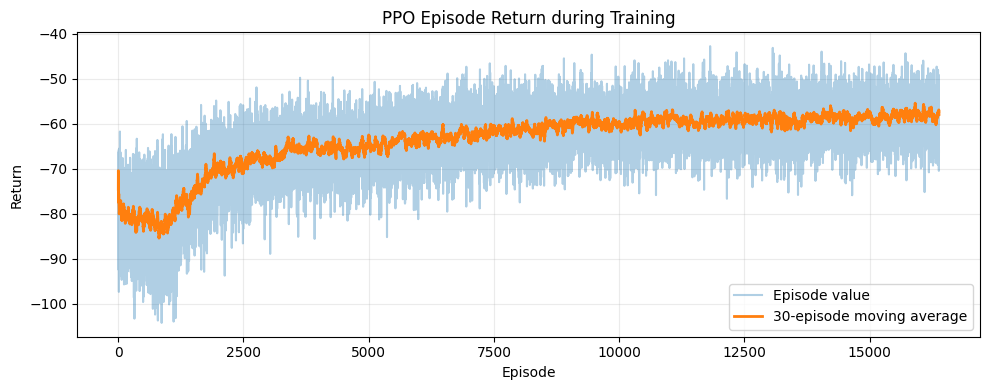

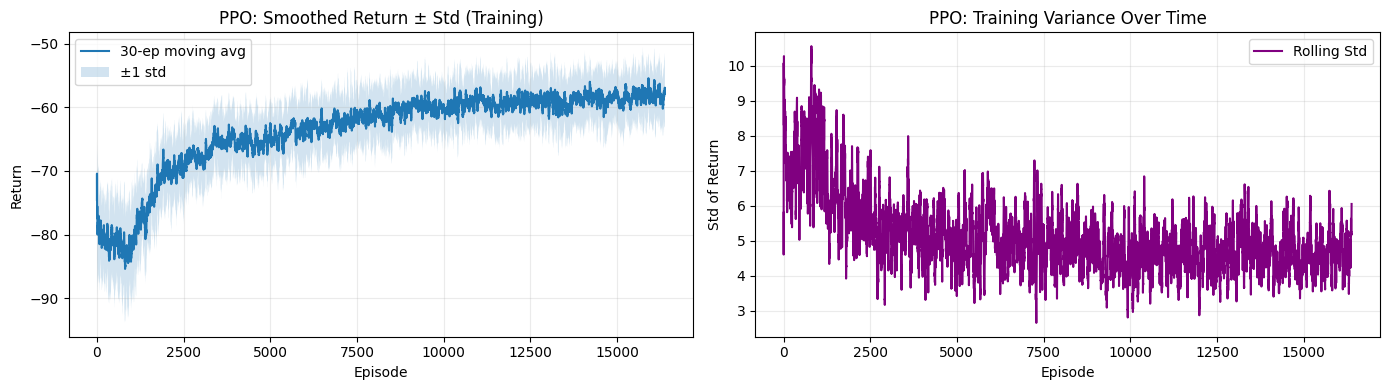


PPO final statistics (last 50 episodes):
  Mean return : -57.9810
  Std  return : 5.2828
  Min  return : -70.4452
  Max  return : -47.2994

PPO evaluation (100 episodes):
  Avg Latency : 1151.97 ms
  P95 Latency : 2411.16 ms
  Avg Reward  : -57.5986
  Device %    : 47.6%
  Edge %      : 52.4%


In [28]:
# ============================================================================
# PPO Training on EdgeOffloadingEnv  (TUNED hyperparameters only)
# ============================================================================

STATE_DIM  = 4   # [input_size, workload, uplink_rate, edge_queue]
ACTION_DIM = 2   # 0=device, 1=edge

# ── TUNED HYPERPARAMETERS ──────────────────────────────────────────────────────
# lr: 3e-4 → giữ nguyên (phù hợp với return norm)
# clip_ratio: 0.2 → giữ nguyên
# rollout_steps: 512 → 2048  (variance thấp hơn, advantage estimate tốt hơn)
# update_epochs: 4 → 10  (khai thác mỗi rollout triệt để hơn)
# minibatch: 128 → 512
# lambda GAE: 0.95 → 0.95 giữ nguyên
# ppo_epochs: 200 → 400
# ent_coef: anneal từ 0.05 → 0.001  (force explore lúc đầu, exploit sau)
# vf_coef: 0.5 → 1.0  (value function quan trọng hơn vì reward scale lớn)
# hidden_size: 256 (set ở cell trên)

ENT_COEF_START = 0.05   # entropy cao lúc đầu → FORCE exploration, tránh collapse
ENT_COEF_END   = 0.001  # giảm dần về cuối → exploit policy đã học
VF_COEF        = 1.0

ppo_epochs     = 80  if FAST_MODE else 400
rollout_steps  = 2048

ppo_episode_returns = []
ppo_epoch_returns   = []

torch.manual_seed(SEED + 2000)
np.random.seed(SEED + 2000)

# Khởi tạo trainer với ent_coef ban đầu (sẽ update mỗi epoch)
ppo_trainer = PPOScratchTrainer(STATE_DIM, ACTION_DIM,
                                 learning_rate=3e-4,
                                 clip_ratio=0.2,
                                 vf_coef=VF_COEF,
                                 ent_coef=ENT_COEF_START)
ppo_buffer  = DiscreteRolloutBuffer()

train_env_ppo  = EdgeOffloadingEnv(max_steps=50)
current_obs, _ = train_env_ppo.reset(seed=SEED + 2000)
current_ep_ret = 0.0

print(f'Training PPO on EdgeOffloadingEnv for {ppo_epochs} epochs ({rollout_steps} steps/epoch)...')
print(f'  lr=3e-4 | clip=0.2 | epochs/update=10 | mb=512 | lambda=0.95 | hidden=256')
print(f'  vf_coef={VF_COEF} | ent_coef: {ENT_COEF_START} → {ENT_COEF_END} (annealing)')
print(f'  + return normalization  + per-minibatch advantage norm  + Adam eps=1e-5')

for epoch_idx in range(ppo_epochs):
    # ── Entropy annealing: linear decay ───────────────────────────────────────
    frac = epoch_idx / max(ppo_epochs - 1, 1)
    current_ent_coef = ENT_COEF_START + frac * (ENT_COEF_END - ENT_COEF_START)
    ppo_trainer.ent_coef = current_ent_coef

    ppo_buffer.clear()
    epoch_ret = 0.0

    for _ in range(rollout_steps):
        action, log_prob, value = ppo_trainer.sample_action(current_obs)
        next_obs, reward, terminated, truncated, _ = train_env_ppo.step(action)
        done = float(terminated or truncated)
        ppo_buffer.add(current_obs, action, log_prob, reward, done, value)
        current_ep_ret += reward
        epoch_ret      += reward

        if terminated or truncated:
            ppo_episode_returns.append(current_ep_ret)
            current_ep_ret = 0.0
            current_obs, _ = train_env_ppo.reset()
        else:
            current_obs = next_obs

    ppo_trainer.optimize_from_buffer(
        ppo_buffer, gamma_value=0.99, lambda_value=0.95,
        epochs_count=10, minibatch_size=512)
    ppo_epoch_returns.append(epoch_ret / rollout_steps)

    if (epoch_idx + 1) % 50 == 0:
        recent_eps = ppo_episode_returns[-20:] if len(ppo_episode_returns) >= 20 else ppo_episode_returns
        print(f'  Epoch {epoch_idx+1:3d}/{ppo_epochs} | Avg ep return (last 20): {np.mean(recent_eps):.4f} | ent_coef={current_ent_coef:.4f}')

train_env_ppo.close()

# ── Stability plots ────────────────────────────────────────────────────────────
plot_curve(ppo_episode_returns, 'PPO Episode Return during Training', 'Return', window=30)

window_ppo = 30
sm_ppo  = moving_average(ppo_episode_returns, window=window_ppo)
std_ppo = pd.Series(ppo_episode_returns).rolling(window=window_ppo, min_periods=1).std().to_numpy()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(sm_ppo, label=f'{window_ppo}-ep moving avg')
axes[0].fill_between(range(len(sm_ppo)), sm_ppo - std_ppo, sm_ppo + std_ppo, alpha=0.2, label='±1 std')
axes[0].set_title('PPO: Smoothed Return ± Std (Training)')
axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Return'); axes[0].legend()
axes[1].plot(std_ppo, color='purple', label='Rolling Std')
axes[1].set_title('PPO: Training Variance Over Time')
axes[1].set_xlabel('Episode'); axes[1].set_ylabel('Std of Return'); axes[1].legend()
plt.tight_layout(); plt.show()

# ── Final episode statistics ───────────────────────────────────────────────────
final_ppo = np.array(ppo_episode_returns[-50:]) if len(ppo_episode_returns) >= 50 else np.array(ppo_episode_returns)
print(f'\nPPO final statistics (last {len(final_ppo)} episodes):')
print(f'  Mean return : {final_ppo.mean():.4f}')
print(f'  Std  return : {final_ppo.std():.4f}')
print(f'  Min  return : {final_ppo.min():.4f}')
print(f'  Max  return : {final_ppo.max():.4f}')

# ── Evaluate PPO policy ────────────────────────────────────────────────────────
def ppo_action_fn(state, env=None):
    return ppo_trainer.greedy_action(state)

ppo_eval = evaluate_edge_policy(make_env, ppo_action_fn, episodes=100)
print(f'\nPPO evaluation (100 episodes):')
print(f"  Avg Latency : {ppo_eval['avg_latency']:.2f} ms")
print(f"  P95 Latency : {ppo_eval['p95_latency']:.2f} ms")
print(f"  Avg Reward  : {ppo_eval['avg_reward']:.4f}")
print(f"  Device %    : {ppo_eval['device_pct']:.1f}%")
print(f"  Edge %      : {ppo_eval['edge_pct']:.1f}%")


## 6.3 Stability Comparison: A2C vs PPO


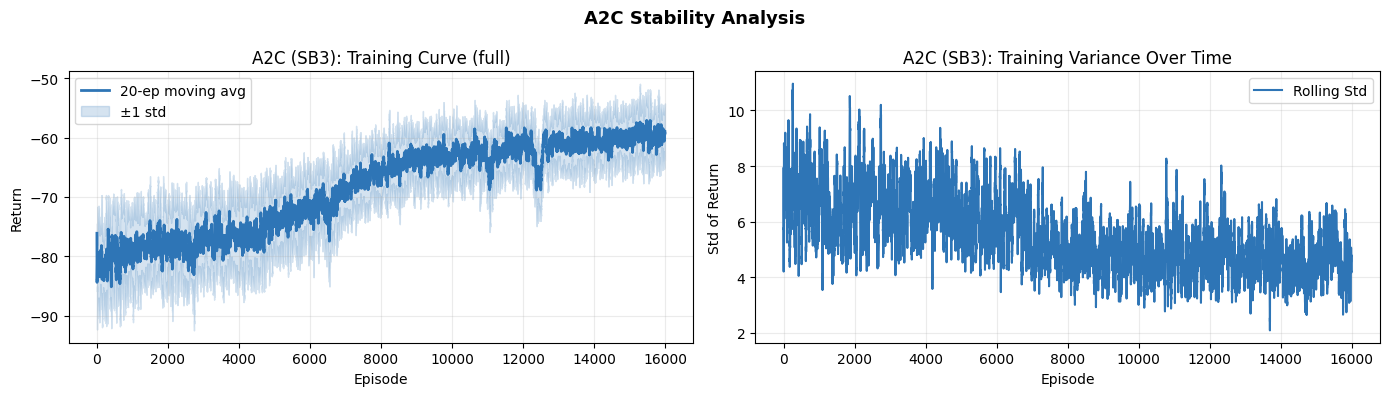

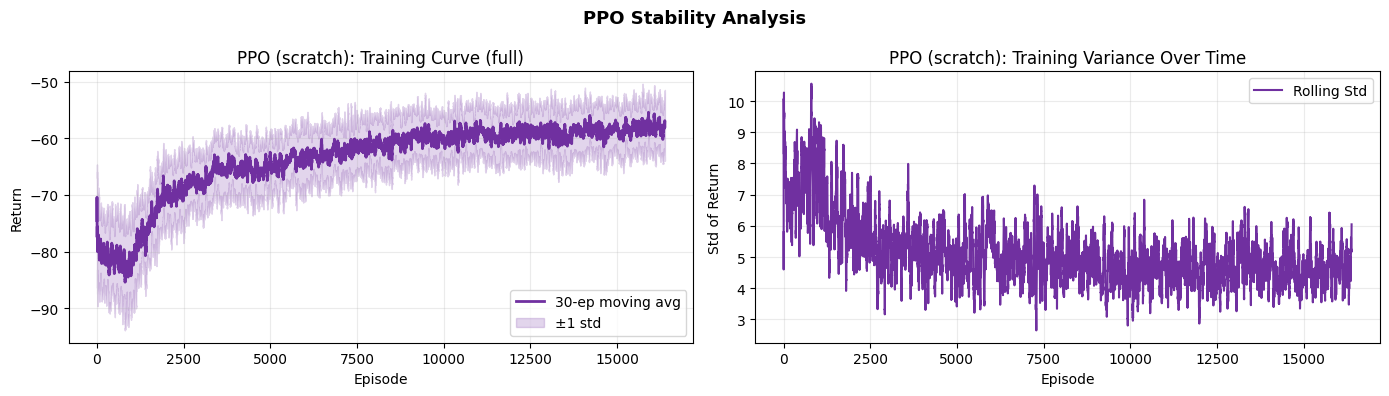

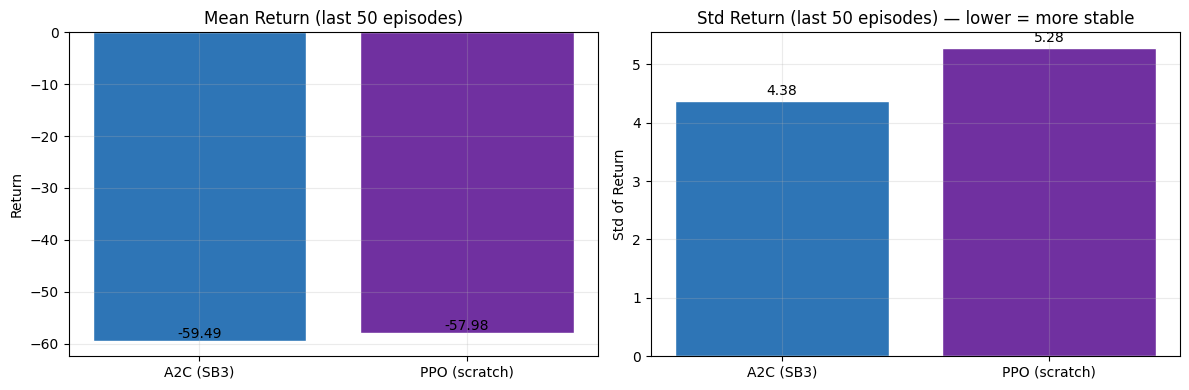


Stability summary (last 50 training episodes):
  Method                     Mean        Std
  A2C (SB3)              -59.4874     4.3781
  PPO (scratch)          -57.9810     5.2828


In [35]:
# ── Biểu đồ 1: A2C training curve (full) ─────────────────────────────────────
if a2c_training_returns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sm_a2c  = moving_average(a2c_training_returns, window=20)
    std_a2c = pd.Series(a2c_training_returns).rolling(window=20, min_periods=1).std().to_numpy()

    axes[0].plot(sm_a2c, lw=2, color='#2E75B6', label='20-ep moving avg')
    axes[0].fill_between(range(len(sm_a2c)), sm_a2c - std_a2c, sm_a2c + std_a2c,
                         alpha=0.2, color='#2E75B6', label='±1 std')
    axes[0].set_title('A2C (SB3): Training Curve (full)')
    axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Return'); axes[0].legend()

    axes[1].plot(std_a2c, color='#2E75B6', label='Rolling Std')
    axes[1].set_title('A2C (SB3): Training Variance Over Time')
    axes[1].set_xlabel('Episode'); axes[1].set_ylabel('Std of Return'); axes[1].legend()

    plt.suptitle('A2C Stability Analysis', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

# ── Biểu đồ 2: PPO training curve (full) ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sm_ppo2  = moving_average(ppo_episode_returns, window=30)
std_ppo2 = pd.Series(ppo_episode_returns).rolling(window=30, min_periods=1).std().to_numpy()

axes[0].plot(sm_ppo2, lw=2, color='#7030A0', label='30-ep moving avg')
axes[0].fill_between(range(len(sm_ppo2)), sm_ppo2 - std_ppo2, sm_ppo2 + std_ppo2,
                     alpha=0.2, color='#7030A0', label='±1 std')
axes[0].set_title('PPO (scratch): Training Curve (full)')
axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Return'); axes[0].legend()

axes[1].plot(std_ppo2, color='#7030A0', label='Rolling Std')
axes[1].set_title('PPO (scratch): Training Variance Over Time')
axes[1].set_xlabel('Episode'); axes[1].set_ylabel('Std of Return'); axes[1].legend()

plt.suptitle('PPO Stability Analysis', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Biểu đồ 3: So sánh mean/std return (bar chart) ───────────────────────────
labels = ['A2C (SB3)', 'PPO (scratch)']
means  = []
stds   = []

if a2c_training_returns:
    arr_a2c = np.array(a2c_training_returns[-50:]) if len(a2c_training_returns) >= 50 else np.array(a2c_training_returns)
    means.append(arr_a2c.mean()); stds.append(arr_a2c.std())
else:
    means.append(0); stds.append(0)

arr_ppo = np.array(ppo_episode_returns[-50:]) if len(ppo_episode_returns) >= 50 else np.array(ppo_episode_returns)
means.append(arr_ppo.mean()); stds.append(arr_ppo.std())

x = np.arange(len(labels))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(x, means, color=['#2E75B6', '#7030A0'], edgecolor='white')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels)
axes[0].set_title('Mean Return (last 50 episodes)'); axes[0].set_ylabel('Return')
for xi, m in zip(x, means):
    axes[0].text(xi, m + 0.5, f'{m:.2f}', ha='center', fontsize=10)

axes[1].bar(x, stds, color=['#2E75B6', '#7030A0'], edgecolor='white')
axes[1].set_xticks(x); axes[1].set_xticklabels(labels)
axes[1].set_title('Std Return (last 50 episodes) — lower = more stable')
axes[1].set_ylabel('Std of Return')
for xi, s in zip(x, stds):
    axes[1].text(xi, s + 0.1, f'{s:.2f}', ha='center', fontsize=10)

plt.tight_layout(); plt.show()

print('\nStability summary (last 50 training episodes):')
print(f"  {'Method':<20} {'Mean':>10} {'Std':>10}")
print(f"  {'A2C (SB3)':<20} {means[0]:>10.4f} {stds[0]:>10.4f}")
print(f"  {'PPO (scratch)':<20} {means[1]:>10.4f} {stds[1]:>10.4f}")


---

# PART 7: Final Comparison

We compare all methods (baseline policies, Actor-Critic, A2C and PPO) using shared evaluation metrics.

### 7.1 Aggregated Results Table



FINAL COMPARISON TABLE
                Avg Latency ↓  P95 Latency ↓  Avg Reward ↑  Gap to Greedy ↓  Device %  Edge %
Method                                                                                       
Random                1627.97        3125.95        -81.40           495.69     50.56   49.44
Device-only           1533.06        2847.47        -76.65           400.78    100.00    0.00
Edge-only             1754.79        4478.39        -87.74           622.51      0.00  100.00
Greedy latency        1132.28        2346.86        -56.61             0.00     48.98   51.02
Actor-Critic          1212.13        2578.11        -60.61            79.85     42.78   57.22
A2C                   1172.74        2433.50        -58.64            40.46     40.08   59.92
PPO                   1151.97        2411.16        -57.60            19.69     47.64   52.36


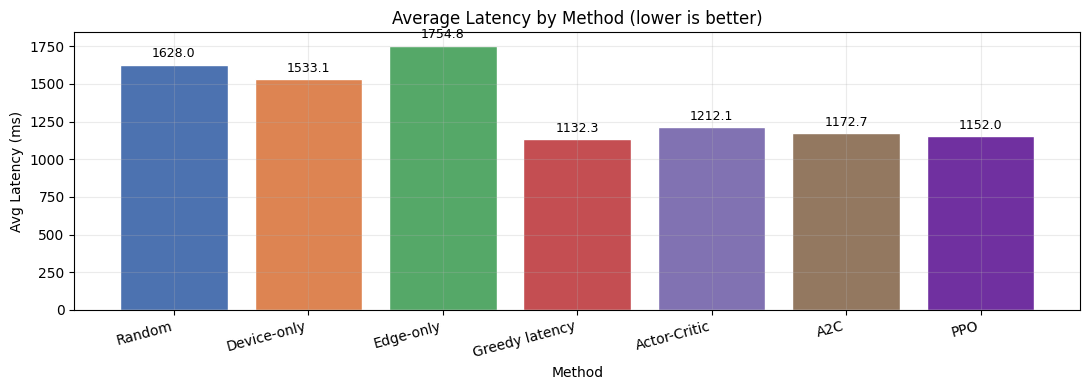

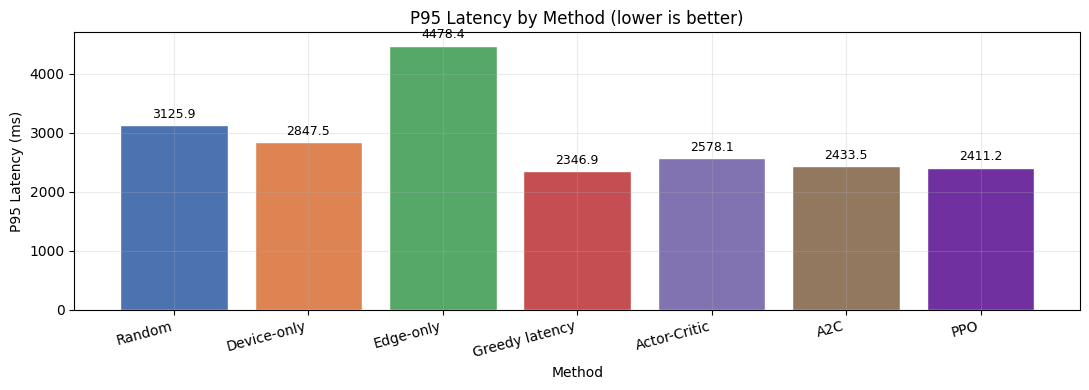

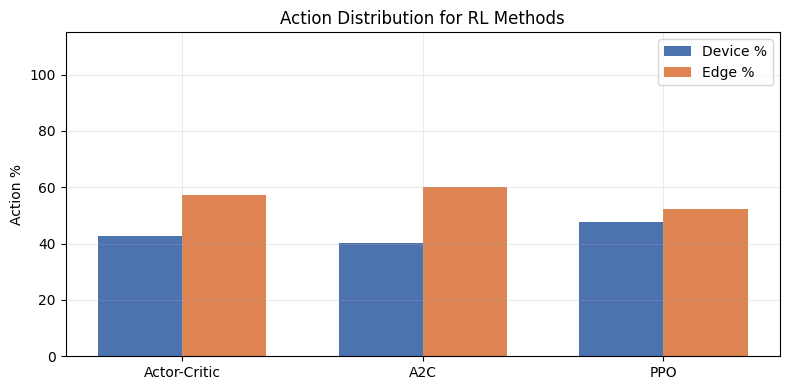

In [36]:
# ============================================================================
# Build comprehensive comparison table
# ============================================================================
comparison_rows = []

def add_result(method_name, result):
    comparison_rows.append({
        'Method': method_name,
        'Avg Latency ↓': result['avg_latency'],
        'P95 Latency ↓': result['p95_latency'],
        'Avg Reward ↑':  result['avg_reward'],
        'Gap to Greedy ↓': result['avg_latency'] - baseline_results['Greedy latency']['avg_latency'],
        'Device %': result['device_pct'],
        'Edge %':   result['edge_pct'],
    })

### YOU NEED TO WRITE YOUR CODE BELOW ###
for name in ['Random', 'Device-only', 'Edge-only', 'Greedy latency']:
    add_result(name, baseline_results[name])

add_result('Actor-Critic', ac_eval)
if a2c_available and a2c_eval is not None:
    add_result('A2C', a2c_eval)
add_result('PPO', ppo_eval)

df_compare = pd.DataFrame(comparison_rows).set_index('Method')

print('\n' + '='*90)
print('FINAL COMPARISON TABLE')
print('='*90)
print(df_compare.to_string(float_format=lambda x: f'{x:.2f}'))

# Plot 1: Avg Latency
methods  = df_compare.index.tolist()
avg_lat  = df_compare['Avg Latency ↓'].values
colors   = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860','#7030A0']
fig, ax  = plt.subplots(figsize=(11, 4))
bars     = ax.bar(methods, avg_lat, color=colors[:len(methods)], edgecolor='white')
ax.bar_label(bars, fmt='%.1f', padding=3, fontsize=9)
ax.set_title('Average Latency by Method (lower is better)')
ax.set_ylabel('Avg Latency (ms)'); ax.set_xlabel('Method')
plt.xticks(rotation=15, ha='right'); plt.tight_layout(); plt.show()

# Plot 2: P95 Latency
p95_lat = df_compare['P95 Latency ↓'].values
fig, ax = plt.subplots(figsize=(11, 4))
bars2   = ax.bar(methods, p95_lat, color=colors[:len(methods)], edgecolor='white')
ax.bar_label(bars2, fmt='%.1f', padding=3, fontsize=9)
ax.set_title('P95 Latency by Method (lower is better)')
ax.set_ylabel('P95 Latency (ms)'); ax.set_xlabel('Method')
plt.xticks(rotation=15, ha='right'); plt.tight_layout(); plt.show()

# Plot 3: Action distribution for RL methods
rl_methods = [m for m in methods if m in ['Actor-Critic', 'A2C', 'PPO']]
if rl_methods:
    dev_pct  = [df_compare.loc[m, 'Device %'] for m in rl_methods]
    edge_pct = [df_compare.loc[m, 'Edge %']   for m in rl_methods]
    x = np.arange(len(rl_methods)); width = 0.35
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(x - width/2, dev_pct,  width, label='Device %', color='#4C72B0')
    ax.bar(x + width/2, edge_pct, width, label='Edge %',   color='#DD8452')
    ax.set_xticks(x); ax.set_xticklabels(rl_methods)
    ax.set_ylim(0, 115); ax.set_title('Action Distribution for RL Methods')
    ax.set_ylabel('Action %'); ax.legend()
    plt.tight_layout(); plt.show()

## CONGRATULATIONS TEAM!

Congratulations on Completing **Lab 05.2 – Continuous and Policy-Based RL with DDPG and PPO**!

**Key Conclusions:**

- You successfully designed and validated an **EdgeOffloadingEnv** that models realistic latency-aware offloading decisions.
- Baseline policies (random, device-only, edge-only, greedy) provided strong reference points for RL performance.
- **Actor-Critic/A2C-style methods** improved learning stability versus pure policy-gradient updates.
- **PPO** demonstrated robust and sample-efficient policy improvement through clipped objective optimization.
- Across experiments, learned policies captured the core trade-off between **local execution cost** and **edge transmission/queue delay**.

**Why This Lab Is Important:**

- It connects RL theory to a practical networking scenario: adaptive edge offloading.
- It shows how policy-based methods can outperform static heuristics in dynamic environments.
- It builds a strong foundation for deploying more advanced RL approaches in real-world edge/cloud systems.

### References

- Schulman et al., Proximal Policy Optimization Algorithms, arXiv:1707.06347
- Schulman et al., High-Dimensional Continuous Control Using GAE, ICLR 2016
- PyTorch documentation: https://pytorch.org/

## ADDITIONAL INFORMATION

**Author**: M.Sc. Phan Trung Phat - Department of Computer Networks and Communications, UIT

**Contact**: phatpt@uit.edu.vn

**Last Updated**: March, 2026